# Respuestas 1.3 y 1.4 — Modelos LSTM

Este notebook se usa solo para responder los incisos 1.3 y 1.4. Se utilizan los resultados  para entrenar el mejor modelo, hacer la predicción y comparar contra el mejor modelo del Laboratorio 1.



In [2]:
import os
import sys
import warnings
from pathlib import Path

Path("/private/tmp/matplotlib-cache").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "lstm" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import config
import utils

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 5)

## Series que se van a evaluar

Se usan las mismas dos series definidas para LSTM en el archivo de configuración del proyecto. En este caso son el total mensual y la frontera 01 La Aurora.

También se mantiene la misma partición temporal del Laboratorio 1: entrenamiento de enero de 2009 a marzo de 2021 y prueba de abril de 2021 a junio de 2026.


In [3]:
SERIES_ANALISIS = config.SERIES_LSTM
USAR_CACHE = True

for serie in SERIES_ANALISIS:
    train = utils.construir_serie(serie, "train")
    prueba = utils.construir_serie(serie, "prueba")
    print(f"{serie}: {config.SERIES_LAB1[serie]['etiqueta']}")
    print(f"  entrenamiento: {train.index.min():%Y-%m} a {train.index.max():%Y-%m} ({len(train)} meses)")
    print(f"  prueba       : {prueba.index.min():%Y-%m} a {prueba.index.max():%Y-%m} ({len(prueba)} meses)")

total: Total mensual
  entrenamiento: 2009-01 a 2021-03 (147 meses)
  prueba       : 2021-04 a 2026-06 (63 meses)
fro_aurora: 01 La Aurora
  entrenamiento: 2009-01 a 2021-03 (147 meses)
  prueba       : 2021-04 a 2026-06 (63 meses)


## Funciones para entrenar, predecir y comparar

La función principal hace cuatro cosas por cada serie:

1. Carga la tabla de tuneo si ya existe. Si no existe, la calcula.
2. Toma la mejor configuración según el RMSE de validación.
3. Entrena dos versiones finales del modelo usando esa configuración base y las tasas de aprendizaje definidas en utils.LR_MODELOS.
4. Evalúa las predicciones contra el conjunto de prueba y las compara con el mejor modelo del Laboratorio 1.


In [4]:
def numero(x):
    return f"{x:,.0f}"


def cambio_porcentual(nuevo, anterior):
    return ((nuevo - anterior) / anterior) * 100


def cargar_o_tunear(serie, valores_train_log):
    posibles = [
        config.DIR_TABLAS / f"tuneo_lstm_{serie}.csv",
        config.DIR_TABLAS / f"tuneo_lstm_{serie}_dos_modelos.csv",
    ]
    for ruta in posibles:
        if ruta.exists() and USAR_CACHE:
            print(f"[cargado] {ruta.name}")
            return pd.read_csv(ruta)
    return utils.tunear_con_cache(
        clave_serie=serie,
        valores_train_log=valores_train_log,
        grilla=utils.grilla_lstm(),
        usar_cache=USAR_CACHE,
        n_cortes=4,
        tamano_val=12,
        semilla=config.SEMILLA,
        verbose=True,
    )


def limpiar_configuracion(fila, tasa_aprendizaje):
    cfg = fila.to_dict()
    cfg["ventana"] = int(cfg["ventana"])
    cfg["unidades"] = int(cfg["unidades"])
    cfg["capas"] = int(cfg["capas"])
    cfg["dropout"] = float(cfg["dropout"])
    cfg["tasa_aprendizaje"] = float(tasa_aprendizaje)
    cfg["epocas"] = int(cfg.get("epocas", 300)) if not pd.isna(cfg.get("epocas", 300)) else 300
    cfg["paciencia"] = int(cfg.get("paciencia", 40)) if not pd.isna(cfg.get("paciencia", 40)) else 40
    cfg["lote"] = int(cfg.get("lote", 16)) if not pd.isna(cfg.get("lote", 16)) else 16
    if "bidireccional" in cfg and pd.isna(cfg["bidireccional"]):
        cfg["bidireccional"] = False
    if "presentacion" not in cfg or pd.isna(cfg.get("presentacion")):
        cfg["presentacion"] = "nivel"
    return cfg


def evaluar_serie(serie):
    etiqueta = config.SERIES_LAB1[serie]["etiqueta"]
    serie_train = utils.construir_serie(serie, "train")
    serie_prueba = utils.construir_serie(serie, "prueba")
    serie_train_log = np.log(serie_train.values)
    serie_prueba_log = np.log(serie_prueba.values)
    serie_completa_log = np.concatenate([serie_train_log, serie_prueba_log])

    tabla_tuneo = cargar_o_tunear(serie, serie_train_log).sort_values("RMSE_val").reset_index(drop=True)
    mejor_tuneo = tabla_tuneo.iloc[0]

    filas = []
    predicciones = pd.DataFrame({"real": serie_prueba.values}, index=serie_prueba.index)
    ajustes = {}

    for nombre_modelo, lr in utils.LR_MODELOS.items():
        cfg = limpiar_configuracion(mejor_tuneo, lr)
        ajuste = utils.ajustar_lstm(serie_train_log, cfg, semilla=config.SEMILLA, verbose=0)
        pred_log = utils.pronosticar_log(ajuste, len(serie_prueba_log))
        pred_un_paso_log = utils.pronosticar_log_un_paso(ajuste, serie_completa_log, len(serie_prueba_log))

        metricas_rec = utils.metricas(serie_prueba_log, pred_log)
        metricas_un_paso = utils.metricas(serie_prueba_log, pred_un_paso_log)

        predicciones[nombre_modelo] = np.exp(pred_log)
        predicciones[f"{nombre_modelo} un paso"] = np.exp(pred_un_paso_log)
        ajustes[nombre_modelo] = ajuste

        filas.append({
            "serie": serie,
            "etiqueta": etiqueta,
            "modelo": nombre_modelo,
            "presentacion": cfg.get("presentacion", "nivel"),
            "familia": cfg.get("familia", ""),
            "ventana": cfg["ventana"],
            "unidades": cfg["unidades"],
            "capas": cfg["capas"],
            "dropout": cfg["dropout"],
            "tasa_aprendizaje": cfg["tasa_aprendizaje"],
            "epocas_entrenadas": ajuste["epocas_corridas"],
            "MAE_recursivo": metricas_rec["MAE"],
            "RMSE_recursivo": metricas_rec["RMSE"],
            "MAPE_recursivo_%": metricas_rec["MAPE_%"],
            "MAE_un_paso": metricas_un_paso["MAE"],
            "RMSE_un_paso": metricas_un_paso["RMSE"],
            "MAPE_un_paso_%": metricas_un_paso["MAPE_%"],
        })

    tabla_modelos = pd.DataFrame(filas).sort_values("RMSE_recursivo").reset_index(drop=True)
    mejor_lstm = tabla_modelos.iloc[0]
    lab1 = config.MEJORES_LAB1[serie]

    comparacion = pd.DataFrame([
        {
            "serie": serie,
            "modelo": f"LSTM {mejor_lstm['modelo']}",
            "MAE": mejor_lstm["MAE_recursivo"],
            "RMSE": mejor_lstm["RMSE_recursivo"],
            "MAPE_%": mejor_lstm["MAPE_recursivo_%"],
            "fuente": "Lab 2",
        },
        {
            "serie": serie,
            "modelo": lab1["modelo"],
            "MAE": lab1["MAE"],
            "RMSE": lab1["RMSE"],
            "MAPE_%": np.nan,
            "fuente": "Lab 1",
        },
    ]).sort_values("RMSE").reset_index(drop=True)

    config.DIR_TABLAS.mkdir(parents=True, exist_ok=True)
    predicciones.to_csv(config.DIR_TABLAS / f"predicciones_lstm_{serie}.csv", index_label="Fecha")
    tabla_modelos.to_csv(config.DIR_TABLAS / f"metricas_lstm_{serie}.csv", index=False)
    comparacion.to_csv(config.DIR_TABLAS / f"comparacion_lstm_lab1_{serie}.csv", index=False)

    return {
        "serie": serie,
        "etiqueta": etiqueta,
        "train": serie_train,
        "prueba": serie_prueba,
        "tabla_tuneo": tabla_tuneo,
        "tabla_modelos": tabla_modelos,
        "predicciones": predicciones,
        "comparacion": comparacion,
        "ajustes": ajustes,
        "mejor_lstm": mejor_lstm,
        "lab1": lab1,
    }

## 1.3. Predicción con el mejor modelo

En esta parte se entrena el mejor modelo encontrado en el tuneo y se utliza para predecir los meses del conjunto de prueba. La comparación principal se hace con el pronóstico recursivo, porque ese caso no usa valores reales dentro del periodo de prueba.


In [5]:
resultados = {}

for serie in SERIES_ANALISIS:
    print("=" * 80)
    print(config.SERIES_LAB1[serie]["etiqueta"])
    print("=" * 80)
    resultados[serie] = evaluar_serie(serie)
    display(resultados[serie]["tabla_modelos"])
    display(resultados[serie]["predicciones"].head())

Total mensual
[cargado] tuneo_lstm_total_dos_modelos.csv


,serie,etiqueta,modelo,presentacion,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,epocas_entrenadas,MAE_recursivo,RMSE_recursivo,MAPE_recursivo_%,MAE_un_paso,RMSE_un_paso,MAPE_un_paso_%
0,total,Total mensual,Modelo 1,nivel,B_apilada_dropout,12,32,2,0.2,0.001,126,92632.092520,114510.150768,56.231332,45167.334434,56869.374582,24.123321
1,total,Total mensual,Modelo 2,nivel,B_apilada_dropout,12,32,2,0.2,0.010,250,276196.538961,576611.077183,126.285296,34926.220369,44856.577579,17.458739


,real,Modelo 1,Modelo 1 un paso,Modelo 2,Modelo 2 un paso
Fecha,,,,,
2021-04-01,59743.190221,141437.436931,141437.436931,102769.293594,102769.293594
2021-05-01,73873.000000,173297.629107,147768.107826,113078.880859,105774.151007
2021-06-01,95146.000000,211578.754869,148979.599405,117193.936735,106990.804143
2021-07-01,97594.664334,254034.662996,153078.516535,126743.909723,109905.235891
2021-08-01,72327.000000,296611.069878,156479.529379,149700.226555,119848.935090


01 La Aurora
[  1/24] nivel         A_simple         v=12 u=16  ->  RMSE_val=      37,733
[  2/24] nivel         A_simple         v=12 u=32  ->  RMSE_val=      37,737
[  3/24] nivel         A_simple         v=12 u=64  ->  RMSE_val=      38,692
[  4/24] nivel         B_apilada        v=12 u=32  ->  RMSE_val=      38,032
[  5/24] nivel         B_apilada        v=12 u=64  ->  RMSE_val=      38,699
[  6/24] nivel         C_bidireccional  v=12 u=32  ->  RMSE_val=      37,698
[  7/24] nivel         A_simple         v=24 u=16  ->  RMSE_val=      37,462
[  8/24] nivel         A_simple         v=24 u=32  ->  RMSE_val=      42,211
[  9/24] nivel         A_simple         v=24 u=64  ->  RMSE_val=      42,344
[ 10/24] nivel         B_apilada        v=24 u=32  ->  RMSE_val=      39,041
[ 11/24] nivel         B_apilada        v=24 u=64  ->  RMSE_val=      42,180
[ 12/24] nivel         C_bidireccional  v=24 u=32  ->  RMSE_val=      39,287
[ 13/24] diferenciada  A_simple         v=12 u=16  ->  RMSE_val

,serie,etiqueta,modelo,presentacion,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,epocas_entrenadas,MAE_recursivo,RMSE_recursivo,MAPE_recursivo_%,MAE_un_paso,RMSE_un_paso,MAPE_un_paso_%
0,fro_aurora,01 La Aurora,Modelo 2,diferenciada,B_apilada,24,32,2,0.2,0.010,146,46540.969032,51615.220463,46.684681,15970.770613,20043.308605,18.385411
1,fro_aurora,01 La Aurora,Modelo 1,diferenciada,B_apilada,24,32,2,0.2,0.001,127,172920.543744,204693.723339,186.947131,16253.643842,20470.077153,19.071176


,real,Modelo 1,Modelo 1 un paso,Modelo 2,Modelo 2 un paso
Fecha,,,,,
2021-04-01,33042.102901,61497.248193,61497.248193,58484.389700,58484.389700
2021-05-01,58366.000000,65306.970859,34778.520170,58049.637777,32630.845492
2021-06-01,73409.000000,70052.496692,62141.991434,57522.223992,57875.400069
2021-07-01,70338.000000,75624.818226,78954.371561,56958.688588,72992.814905
2021-08-01,50329.000000,81926.800670,75968.029702,56408.584386,69897.257981


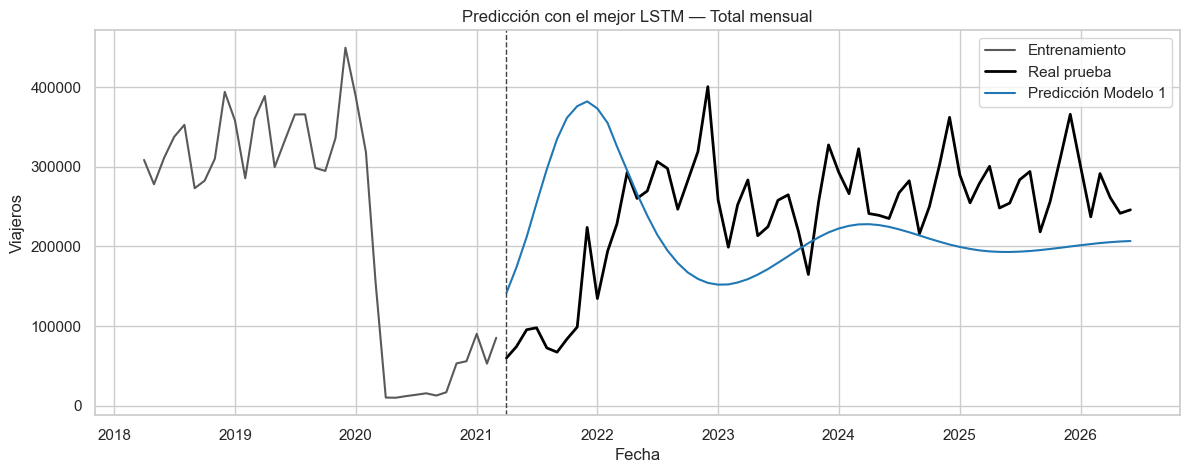

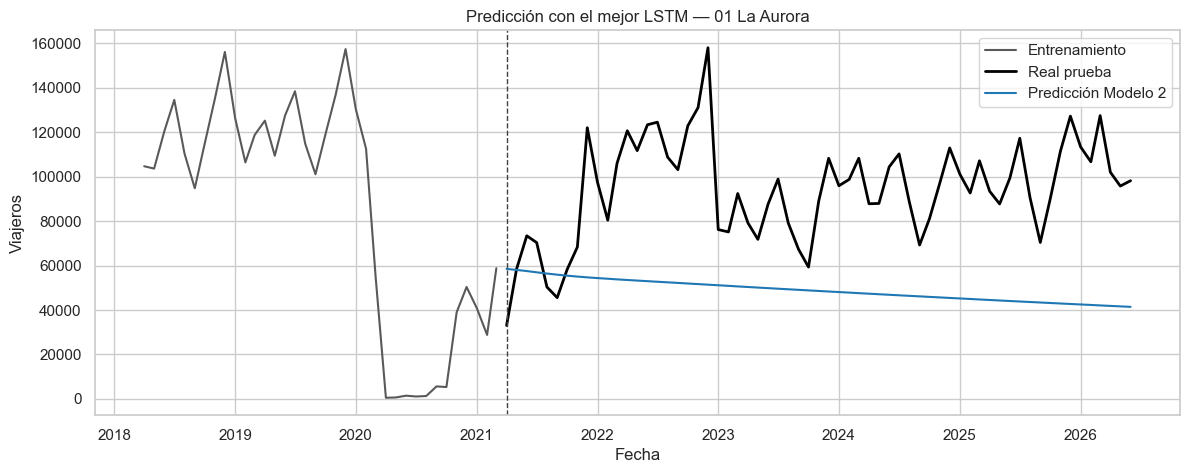

In [6]:
for serie, res in resultados.items():
    pred = res["predicciones"]
    mejor = res["mejor_lstm"]["modelo"]
    etiqueta = res["etiqueta"]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(res["train"].tail(36).index, res["train"].tail(36).values, label="Entrenamiento", color="0.35")
    ax.plot(res["prueba"].index, res["prueba"].values, label="Real prueba", color="black", linewidth=2)
    ax.plot(pred.index, pred[mejor], label=f"Predicción {mejor}", color="#1f77b4")
    ax.axvline(res["prueba"].index.min(), color="0.25", linestyle="--", linewidth=1)
    ax.set_title(f"Predicción con el mejor LSTM — {etiqueta}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Viajeros")
    ax.legend()
    plt.show()

## 1.4. Comparación de modelos

Para decidir cuál predijo mejor se usa principalmente el RMSE recursivo, porque penaliza más los errores grandes. También se revisa el MAE para confirmar si la conclusión se mantiene con una métrica menos sensible a errores extremos.

La comparación contra el Laboratorio 1 se hace con los errores en la escala original de viajeros. Si el LSTM tiene menor RMSE y menor MAE que el modelo anterior, entonces se considera mejor. Si tiene errores mayores, el modelo del Laboratorio 1 sigue siendo superior.


In [7]:
tablas_comparacion = []

for serie, res in resultados.items():
    etiqueta = res["etiqueta"]
    tabla = res["comparacion"].copy()
    tablas_comparacion.append(tabla)
    print("=" * 80)
    print(etiqueta)
    print("=" * 80)
    display(res["tabla_modelos"])
    display(tabla)

tabla_comparacion_general = pd.concat(tablas_comparacion, ignore_index=True)
tabla_comparacion_general

Total mensual


,serie,etiqueta,modelo,presentacion,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,epocas_entrenadas,MAE_recursivo,RMSE_recursivo,MAPE_recursivo_%,MAE_un_paso,RMSE_un_paso,MAPE_un_paso_%
0,total,Total mensual,Modelo 1,nivel,B_apilada_dropout,12,32,2,0.2,0.001,126,92632.092520,114510.150768,56.231332,45167.334434,56869.374582,24.123321
1,total,Total mensual,Modelo 2,nivel,B_apilada_dropout,12,32,2,0.2,0.010,250,276196.538961,576611.077183,126.285296,34926.220369,44856.577579,17.458739


,serie,modelo,MAE,RMSE,MAPE_%,fuente
0,total,LSTM Modelo 1,92632.09252,114510.150768,56.231332,Lab 2
1,total,Suav. exp. simple,158777.00000,173709.000000,NaN,Lab 1


01 La Aurora


,serie,etiqueta,modelo,presentacion,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,epocas_entrenadas,MAE_recursivo,RMSE_recursivo,MAPE_recursivo_%,MAE_un_paso,RMSE_un_paso,MAPE_un_paso_%
0,fro_aurora,01 La Aurora,Modelo 2,diferenciada,B_apilada,24,32,2,0.2,0.010,146,46540.969032,51615.220463,46.684681,15970.770613,20043.308605,18.385411
1,fro_aurora,01 La Aurora,Modelo 1,diferenciada,B_apilada,24,32,2,0.2,0.001,127,172920.543744,204693.723339,186.947131,16253.643842,20470.077153,19.071176


,serie,modelo,MAE,RMSE,MAPE_%,fuente
0,fro_aurora,Suav. exp. simple,36822.000000,42053.000000,NaN,Lab 1
1,fro_aurora,LSTM Modelo 2,46540.969032,51615.220463,46.684681,Lab 2


,serie,modelo,MAE,RMSE,MAPE_%,fuente
0,total,LSTM Modelo 1,92632.092520,114510.150768,56.231332,Lab 2
1,total,Suav. exp. simple,158777.000000,173709.000000,NaN,Lab 1
2,fro_aurora,Suav. exp. simple,36822.000000,42053.000000,NaN,Lab 1
3,fro_aurora,LSTM Modelo 2,46540.969032,51615.220463,46.684681,Lab 2


In [8]:
for serie, res in resultados.items():
    etiqueta = res["etiqueta"]
    modelos = res["tabla_modelos"]
    mejor = res["mejor_lstm"]
    segundo = modelos.iloc[1] if len(modelos) > 1 else None
    lab1 = res["lab1"]

    dif_rmse_lab1 = mejor["RMSE_recursivo"] - lab1["RMSE"]
    dif_mae_lab1 = mejor["MAE_recursivo"] - lab1["MAE"]
    pct_rmse_lab1 = cambio_porcentual(mejor["RMSE_recursivo"], lab1["RMSE"])
    pct_mae_lab1 = cambio_porcentual(mejor["MAE_recursivo"], lab1["MAE"])

    mejor_que_lab1 = mejor["RMSE_recursivo"] < lab1["RMSE"] and mejor["MAE_recursivo"] < lab1["MAE"]
    conclusion_lab1 = "sí fue mejor" if mejor_que_lab1 else "no fue mejor"

    print(f"Serie: {etiqueta}")
    print(f"1.3. El mejor modelo LSTM fue {mejor['modelo']}. Se usó este modelo para predecir el conjunto de prueba completo, de abril de 2021 a junio de 2026.")
    print(f"Su error fue MAE = {numero(mejor['MAE_recursivo'])} viajeros y RMSE = {numero(mejor['RMSE_recursivo'])} viajeros en pronóstico recursivo.")

    if segundo is not None:
        print(f"Para 1.4, entre los modelos LSTM predijo mejor {mejor['modelo']}, porque tuvo menor RMSE que {segundo['modelo']} ({numero(mejor['RMSE_recursivo'])} contra {numero(segundo['RMSE_recursivo'])}).")
    else:
        print("Para 1.4, solo hay un modelo LSTM disponible en la tabla final, por lo que la comparación interna no aplica.")

    print(f"Comparado con el mejor modelo del Laboratorio 1, que fue {lab1['modelo']} con MAE = {numero(lab1['MAE'])} y RMSE = {numero(lab1['RMSE'])}, el LSTM {conclusion_lab1}.")
    print(f"La diferencia fue de {numero(dif_mae_lab1)} viajeros en MAE ({pct_mae_lab1:.2f}%) y {numero(dif_rmse_lab1)} viajeros en RMSE ({pct_rmse_lab1:.2f}%).")
    print("Esto se determinó usando las mismas particiones de entrenamiento y prueba y calculando los errores en la escala original de viajeros, para que la comparación fuera directa.")
    print()

Serie: Total mensual
1.3. El mejor modelo LSTM fue Modelo 1. Se usó este modelo para predecir el conjunto de prueba completo, de abril de 2021 a junio de 2026.
Su error fue MAE = 92,632 viajeros y RMSE = 114,510 viajeros en pronóstico recursivo.
Para 1.4, entre los modelos LSTM predijo mejor Modelo 1, porque tuvo menor RMSE que Modelo 2 (114,510 contra 576,611).
Comparado con el mejor modelo del Laboratorio 1, que fue Suav. exp. simple con MAE = 158,777 y RMSE = 173,709, el LSTM sí fue mejor.
La diferencia fue de -66,145 viajeros en MAE (-41.66%) y -59,199 viajeros en RMSE (-34.08%).
Esto se determinó usando las mismas particiones de entrenamiento y prueba y calculando los errores en la escala original de viajeros, para que la comparación fuera directa.

Serie: 01 La Aurora
1.3. El mejor modelo LSTM fue Modelo 2. Se usó este modelo para predecir el conjunto de prueba completo, de abril de 2021 a junio de 2026.
Su error fue MAE = 46,541 viajeros y RMSE = 51,615 viajeros en pronóstico re